# Import Data


Dataset Link: https://www.kaggle.com/datasets/datasnaek/chess/data


In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Import data and observe shape and columns
chess_data_raw = pd.read_csv("data/games.csv")
print(chess_data_raw.shape)
print(chess_data_raw.columns)
chess_data_raw.head()

(20058, 16)
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='object')


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


# Clean data


In [13]:
chess_data = chess_data_raw.drop(columns=["id", "white_id", "black_id"])
chess_data = chess_data.dropna()

# Drop all non-rated games for doing rating analysis
print(len(chess_data))
chess_data = chess_data[chess_data["rated"] == True]
print(len(chess_data))
# Remove rated, created at, and last move at columns
chess_data = chess_data.drop(["rated","created_at","last_move_at"],axis=1)
# Map winner column
chess_data["winner"] = chess_data["winner"].map({"black": -1, "white": 1}).fillna(0)
# Map victory column
chess_data["victory_status"] = chess_data["victory_status"].map({"resign": 0, "mate": 1,"draw": 2, "outoftime": 3})
# Convert moves column to array of moves
chess_data["moves"] = chess_data["moves"].str.split(" ")
# Assume average game rating (averge of player ratings)
chess_data["avg_rating"] = [int((chess_data["black_rating"].iloc[r] + chess_data["white_rating"].iloc[r])/2) for r in range(len(chess_data))]

chess_data.head()

20058
16155


,turns,victory_status,winner,increment_code,white_rating,black_rating,moves,opening_eco,opening_name,opening_ply,avg_rating
1,16,0,-1.0,5+10,1322,1261,"[d4, Nc6, e4, e5, f4, f6, dxe5, fxe5, fxe5, Nx...",B00,Nimzowitsch Defense: Kennedy Variation,4,1291
2,61,1,1.0,5+10,1496,1500,"[e4, e5, d3, d6, Be3, c6, Be2, b5, Nd2, a5, a4...",C20,King's Pawn Game: Leonardis Variation,3,1498
3,61,1,1.0,20+0,1439,1454,"[d4, d5, Nf3, Bf5, Nc3, Nf6, Bf4, Ng4, e3, Nc6...",D02,Queen's Pawn Game: Zukertort Variation,3,1446
4,95,1,1.0,30+3,1523,1469,"[e4, e5, Nf3, d6, d4, Nc6, d5, Nb4, a3, Na6, N...",C41,Philidor Defense,5,1496
6,33,0,1.0,10+0,1520,1423,"[d4, d5, e4, dxe4, Nc3, Nf6, f3, exf3, Nxf3, N...",D00,Blackmar-Diemer Gambit: Pietrowsky Defense,10,1471


# Descriptive Statistics


In [14]:
print("Players of Black Ratings ---------------")
print(chess_data["black_rating"].mean())
print(chess_data["black_rating"].median())
print()
print("Players of White Ratings ---------------")
print(chess_data["white_rating"].mean())
print(chess_data["white_rating"].median())
print()
# Make array with every player (both black or white)
all_rating = pd.concat([chess_data['white_rating'], chess_data['black_rating']], ignore_index=True)
print("All Player Ratings ---------------")
print(all_rating.mean())
print(all_rating.median())
print()

Players of Black Ratings ---------------
1593.5031878675334
1573.0

Players of White Ratings ---------------
1597.1020117610647
1577.0

All Player Ratings ---------------
1595.302599814299
1575.0



(array([ 278., 1409., 4351., 7539., 7618., 5888., 3320., 1480.,  396.,
          31.]),
 array([ 784. ,  967.8, 1151.6, 1335.4, 1519.2, 1703. , 1886.8, 2070.6,
        2254.4, 2438.2, 2622. ]),
 <BarContainer object of 10 artists>)

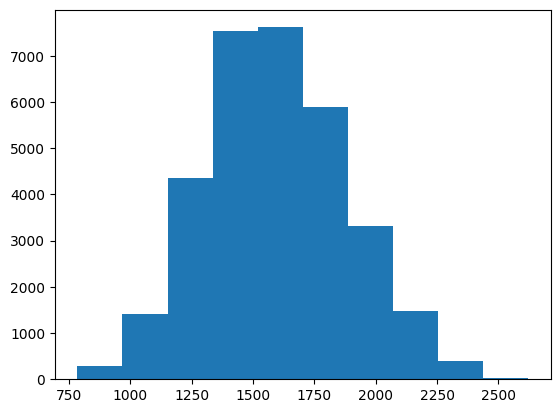

In [15]:
plt.hist(all_rating, bins=10)

# Correlation


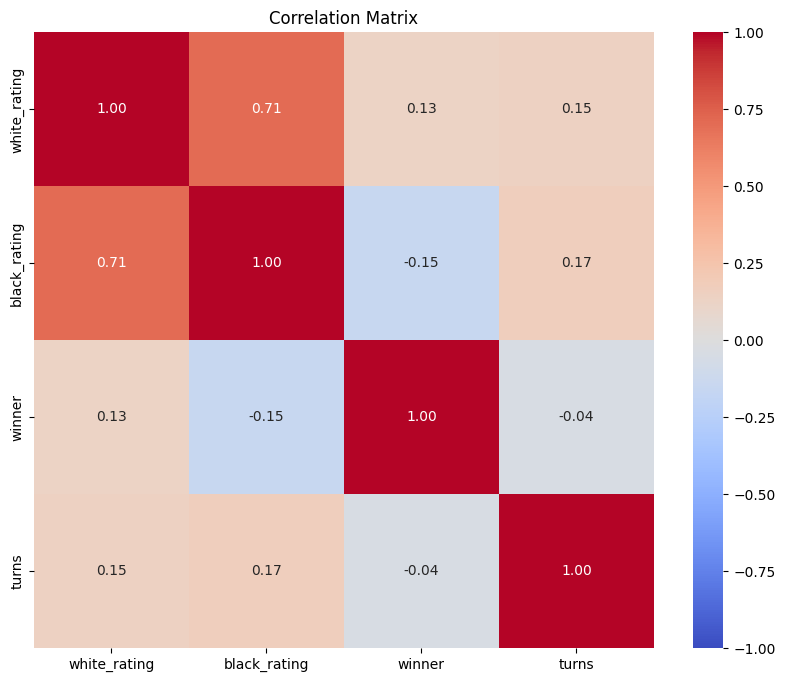

In [16]:
chess_corr_data = chess_data[["white_rating", "black_rating", "winner", "turns"]]

corr_matrix = chess_corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1)
plt.title("Correlation Matrix")
plt.show()

# Opening Evaluation


In [17]:
# Find the stats for each ECO
eco_stats = chess_data.groupby("opening_eco").agg(
    white_rating_mean=("white_rating", "mean"),
    white_rating_std=("white_rating", "std"),
    black_rating_mean=("black_rating", "mean"),
    black_rating_std=("black_rating", "std"),
    count=("opening_eco", "size"),
    winner=("winner", "mean"),
)

In [18]:
most_popular = eco_stats.nlargest(20, "count")
least_popular = eco_stats[eco_stats["count"] == 1]

most_popular

,white_rating_mean,white_rating_std,black_rating_mean,black_rating_std,count,winner
opening_eco,,,,,,
A00,1436.684145,270.479128,1490.149813,293.035885,801,-0.167291
C00,1566.980743,260.836707,1547.447043,286.054734,727,0.046768
D00,1528.164154,283.840973,1551.050251,286.225308,597,-0.033501
B01,1532.117547,289.958197,1526.860307,308.139414,587,0.032368
C41,1533.804618,240.503144,1494.978686,225.083131,563,0.182948
C20,1385.660448,206.730201,1401.283582,218.463329,536,-0.035448
A40,1585.581213,299.697182,1547.181996,280.630711,511,0.097847
B20,1538.226293,262.212967,1606.303879,270.690590,464,-0.193966
B00,1538.214286,271.199328,1476.448052,275.762914,462,0.220779


In [19]:
# Get most popular opening for each rating block

test = len(chess_data)
print(f"Lowest Rating: {chess_data["avg_rating"].min()}\n"
      f"Highest Rating: {chess_data["avg_rating"].max()}")
rating_block = np.linspace(chess_data["avg_rating"].min()-1,chess_data["avg_rating"].max(),11)
for block in range(1,len(rating_block)):
    block_bool = (chess_data["avg_rating"] <= rating_block[block]) & (chess_data["avg_rating"] > rating_block[block-1])
    block_sample = chess_data[block_bool]
    
    # Find the stats for each ECO
    eco_stats = block_sample.groupby("opening_eco").agg(
        white_rating_mean=("white_rating", "mean"),
        white_rating_std=("white_rating", "std"),
        black_rating_mean=("black_rating", "mean"),
        black_rating_std=("black_rating", "std"),
        count=("opening_eco", "size"),
        winner=("winner", "mean"),
    )
    most_popular = eco_stats.nlargest(3, "count")
    least_popular = eco_stats[eco_stats["count"] == 1]
    print("\n==========\n"
          f"Popular Opening for Rating Block: ({rating_block[block-1]},{rating_block[block]})")
    print(most_popular)

Lowest Rating: 816
Highest Rating: 2475

Popular Opening for Rating Block: (815.0,981.0)
             white_rating_mean  white_rating_std  black_rating_mean  \
opening_eco                                                           
C20                 933.272727         84.218871         917.181818   
B01                 972.500000        100.158446         904.000000   
A00                 939.750000         93.500000         958.750000   

             black_rating_std  count    winner  
opening_eco                                     
C20                 67.851040     11  0.090909  
B01                104.200356      8  0.750000  
A00                 29.837057      4 -0.500000  

Popular Opening for Rating Block: (981.0,1147.0)
             white_rating_mean  white_rating_std  black_rating_mean  \
opening_eco                                                           
A00                1147.342466        158.515528        1051.904110   
C20                1097.023256        138.13683